# Week 7 notebook

# Part 1

1.

-0.001 0.0 0.0
0.999 0.0 0.0
0.16366152786530275 -0.45181250592972166 0.0
0.17355545968606262 -0.44785137919545714 0.0
<rebound.Orbit instance, a=1.0 e=0.0 inc=0.0 Omega=0.0 omega=0.0 f=0.0> 6.283185307179586
<rebound.Orbit instance, a=0.7999999999999997 e=0.39999999999999974 inc=0.0 Omega=0.0 omega=5.1487212933832724 f=6.194384223582734> 4.495881427866062
<rebound.Orbit instance, a=0.7999999999999994 e=0.3999999999999995 inc=0.0 Omega=0.0 omega=5.1487212933832724 f=6.216562618141213> 4.49588142786606


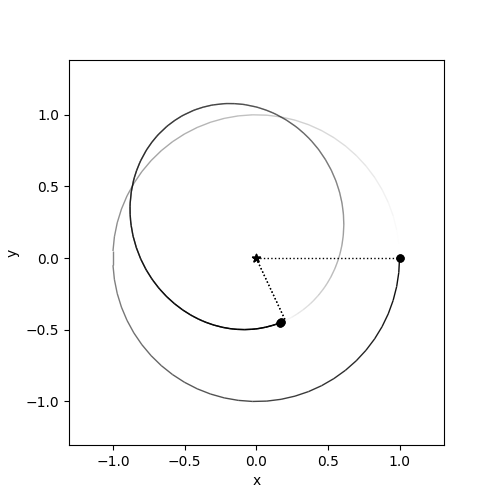

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import rebound
import time
import numpy as np
plt.close()

# set up the simulation
mu2 = 0.001
mu1 = 1 - mu2
sim = rebound.Simulation()
sim.add(m=mu1, hash='sun')
sim.add(m=mu2, a=1, e=0, hash='jupiter')

sim.add(m=0, a=0.8, e=0.4, pomega=295*np.pi/180, l=293*np.pi/180, hash='particle1')
sim.add(m=0, a=0.8, e=0.4, pomega=295*np.pi/180, l=293.5*np.pi/180, hash='particle2')

sim.move_to_com()

# plot the positions and instantaneous orbit
op = rebound.OrbitPlot(sim, periastron=True)

# output info about the particles and the orbit
for p in sim.particles:
    print(p.x, p.y, p.z)
for o in sim.orbits(): 
    print(o, o.P)

In [2]:
p_orb = sim.particles['jupiter'].P

Norbits = 1
Noutputs = 100

times = np.zeros(Noutputs)

xvec1 = [sim.particles['particle1'].x]
yvec1 = [sim.particles['particle1'].y]

vxvec1 = [sim.particles['particle1'].vx]
vyvec1 = [sim.particles['particle1'].vy]

xvec2 = [sim.particles['particle2'].x]
yvec2 = [sim.particles['particle2'].y]

vxvec2 = [sim.particles['particle2'].vx]
vyvec2 = [sim.particles['particle2'].vy]

op2, = plt.plot(xvec1, yvec1)

for i in range(Noutputs):
    # integrate for 1% of the orbit
    op.sim.integrate(sim.t + (Norbits/Noutputs)*p_orb)

    times[i] = sim.t

    # store the trajectory + velocity of particle 1
    xvec1.append(sim.particles['particle1'].x)
    yvec1.append(sim.particles['particle1'].y)

    # store the trajectory + velocity of particle 1
    vxvec1.append(sim.particles['particle1'].vx)
    vyvec1.append(sim.particles['particle1'].vy)

    # store the trajectory + velocity of particle 2
    xvec2.append(sim.particles['particle2'].x)
    yvec2.append(sim.particles['particle2'].y)

    vxvec2.append(sim.particles['particle2'].vx)
    vyvec2.append(sim.particles['particle2'].vy)

    # update the plot to animate it
    op.update() #updateLimits=True) 
    op2.set_data((xvec1,yvec1)) 
    time.sleep(0.001)
    op.fig.canvas.draw()

There is a clear deviation, they flew off in different directions. To quantify this deviation, I look into the LCE:

In [3]:
def dfunc(x1, y1, x2, y2, vx1, vy1, vx2, vy2):
    return np.sqrt((x1-x2)**2 + (y1-y2)**2 + (vx1-vx2)**2 + (vy1-vy2)**2)

def LCE(x1_0, x1, y1_0, y1, x2_0, x2, y2_0, y2, vx1_0, vx1, vy1_0, vy1, vx2_0, vx2, vy2_0, vy2, t0, t):

    d = dfunc(x1, y1, x2, y2, vx1, vy1, vx2, vy2)
    d0 = dfunc(x1_0, y1_0, x2_0, y2_0, vx1_0, vy1_0, vx2_0, vy2_0)
    
    gamma = np.log(d/d0)/(t-t0)
    
    return gamma

In [4]:
LCEs = np.zeros(Noutputs)

for i in range(Noutputs):
    if i==0:
        continue # skip i=0

    x1_0 = xvec1[0]
    y1_0 = yvec1[0]
    x2_0 = xvec2[0]
    y2_0 = yvec2[0]
    
    vx1_0 = vxvec1[0]
    vy1_0 = vyvec1[0]
    vx2_0 = vxvec2[0]
    vy2_0 = vyvec2[0]

    LCEs[i] = LCE(x1_0  = x1_0,
                  x1    = xvec1[i],
                  y1_0  = y1_0,
                  y1    = yvec1[i],
                  x2_0  = x2_0,
                  x2    = xvec2[i],
                  y2_0  = y2_0,
                  y2    = yvec2[i],
                  vx1_0 = vx1_0, 
                  vx1   = vxvec1[i],
                  vy1_0 = vy1_0,
                  vy1   = vyvec1[i],
                  vx2_0 = vx2_0,
                  vx2   = vxvec2[i],
                  vy2_0 = vy2_0,
                  vy2   = vyvec2[i],
                  t0    = times[0], 
                  t     = times[i]
               )

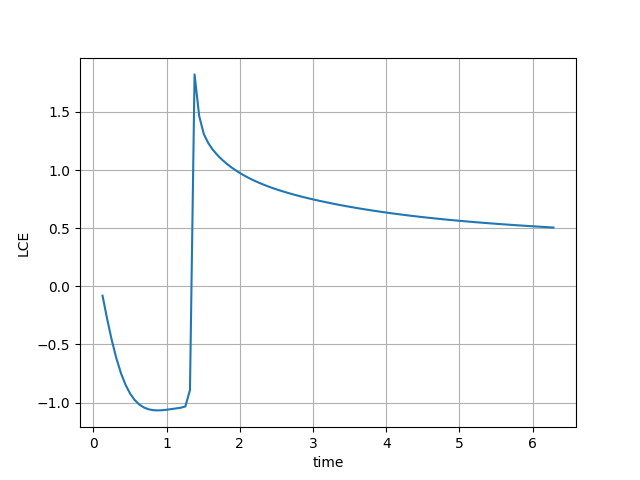

In [5]:
plt.close('all')
plt.plot(times[1:], LCEs[1:])
plt.xlabel('time')
plt.ylabel('LCE')
plt.grid()

debug:

In [84]:
d_0 = np.sqrt((xvec1[0]-xvec2[0])**2 + (yvec1[0]-yvec2[0])**2 + (vxvec1[0]-vxvec2[0])**2 + (vyvec1[0]-vyvec2[0])**2)
d_1 = np.sqrt((xvec1[1]-xvec2[1])**2 + (yvec1[1]-yvec2[1])**2 + (vxvec1[1]-vxvec2[1])**2 + (vyvec1[1]-vyvec2[1])**2)

In [85]:
d_0

np.float64(0.02909034881964706)

In [87]:
d_1

np.float64(0.028942697533605094)

In [90]:
np.log(d_1/d_0)/(times[1] - times[0])

np.float64(-0.08102703895981211)

2.

First solve for the y velocity 

In [6]:
def r1(x, y, mu2):
    return np.sqrt((x+mu2)**2 + y**2)

def r2(x, y, mu1):
    return np.sqrt((x-mu1)**2 + y**2)

def vy(x, y, mu1, mu2, vx, CJ, n=1):

    term1 = (n**2)*(x**2 + y**2)
    term2 = 2*(mu1/(r1(x, y, mu2)) + mu2/(r2(x, y, mu1)))
    term3 = -(vx**2)
    term4 = -CJ
    
    return np.sqrt(term1 + term2 + term3 + term4)

In [7]:
vy0_particle1 = vy(x=0.55, y=0, mu1=mu1, mu2=mu2, vx=0, CJ=3.07, n=1)
vy0_particle2 = vy(x=0.56, y=0, mu1=mu1, mu2=mu2, vx=0, CJ=3.07, n=1)
print(vy0_particle1)
print(vy0_particle2)

0.9290256424097384
0.8998072765093895


And move to COM frame for REBOUND

In [55]:
def v_from_corot_to_com(vx, vy, x, y, t, n=1):
    "equation 3.11 in Murray&Dermott"
    xi_dot = (vx - n*y)*np.cos(n*t) - (vy + n*x)*np.sin(n*t)
    eta_dot = (vx - n*y)*np.sin(n*t) + (vy + n*x)*np.cos(n*t)
    return xi_dot, eta_dot

In [56]:
_, vy0_particle1_com = v_from_corot_to_com(vx=0, vy=vy0_particle1, x=0.55, y=0, t=0, n=1)
_, vy0_particle2_com = v_from_corot_to_com(vx=0, vy=vy0_particle2, x=0.56, y=0, t=0, n=1)
print(vy0_particle1_com)
print(vy0_particle2_com)

1.4790256424097383
1.4598072765093897


-0.001 0.0 0.0
0.999 0.0 0.0
0.55 0.0 0.0
0.56 0.0 0.0
<rebound.Orbit instance, a=1.0 e=0.0 inc=0.0 Omega=0.0 omega=0.0 f=0.0> 6.283185307179586
<rebound.Orbit instance, a=0.6902041058011661 e=0.20313426799804646 inc=0.0 Omega=0.0 omega=0.0 f=0.0> 3.6028499569380177
<rebound.Orbit instance, a=0.6942557964002299 e=0.19338087934786657 inc=0.0 Omega=0.0 omega=0.0 f=0.0> 3.634621070674469


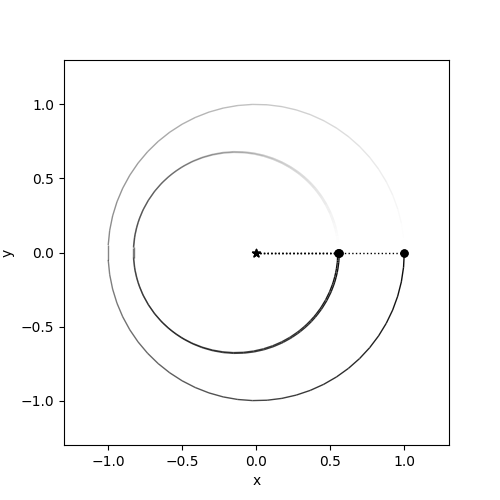

In [57]:
# set up the simulation
sim = rebound.Simulation()
sim.add(m=mu1, hash='sun')
sim.add(m=mu2, a=1, e=0, hash='jupiter')

sim.move_to_com()

sim.add(m=0, x=0.55, y=0, vx=0, vy = vy0_particle1_com, hash='particle1')
sim.add(m=0, x=0.56, y=0, vx=0, vy = vy0_particle2_com, hash='particle2')



# plot the positions and instantaneous orbit
op = rebound.OrbitPlot(sim, periastron=True)

# output info about the particles and the orbit
for p in sim.particles:
    print(p.x, p.y, p.z)
for o in sim.orbits(): 
    print(o, o.P)

In [58]:
p_orb = sim.particles['jupiter'].P

Norbits = 300
Noutputs = 500

times = np.zeros(Noutputs)

xvec1 = [sim.particles['particle1'].x]
yvec1 = [sim.particles['particle1'].y]

vxvec1 = [sim.particles['particle1'].vx]
vyvec1 = [sim.particles['particle1'].vy]

xvec2 = [sim.particles['particle2'].x]
yvec2 = [sim.particles['particle2'].y]

vxvec2 = [sim.particles['particle2'].vx]
vyvec2 = [sim.particles['particle2'].vy]

a1 = np.zeros(Noutputs)
e1 = np.zeros(Noutputs)

a2 = np.zeros(Noutputs)
e2 = np.zeros(Noutputs)

op2, = plt.plot(xvec1, yvec1)

for i in range(Noutputs):
    op.sim.integrate(sim.t + (Norbits/Noutputs)*p_orb)

    times[i] = sim.t

    # store the trajectory + velocity of particle 1
    xvec1.append(sim.particles['particle1'].x)
    yvec1.append(sim.particles['particle1'].y)

    vxvec1.append(sim.particles['particle1'].vx)
    vyvec1.append(sim.particles['particle1'].vy)

    a1[i] = sim.particles['particle1'].a
    e1[i] = sim.particles['particle1'].e

    # store the trajectory + velocity of particle 2
    xvec2.append(sim.particles['particle2'].x)
    yvec2.append(sim.particles['particle2'].y)

    vxvec2.append(sim.particles['particle2'].vx)
    vyvec2.append(sim.particles['particle2'].vy)

    a2[i] = sim.particles['particle2'].a
    e2[i] = sim.particles['particle2'].e

    # update the plot to animate it
    op.update() #updateLimits=True) 
    op2.set_data((xvec1,yvec1)) 
    time.sleep(0.001)
    op.fig.canvas.draw()

Regular orbit (fig 9.4):

In [59]:
print('e0 = '+str(e1[0]))
print('a0 = '+str(a1[0]))

e0 = 0.20912584646951937
a0 = 0.6986057388305068


Textbook values:  a0 = 0.6944 and e0 = 0.2065

Text(0, 0.5, 'a')

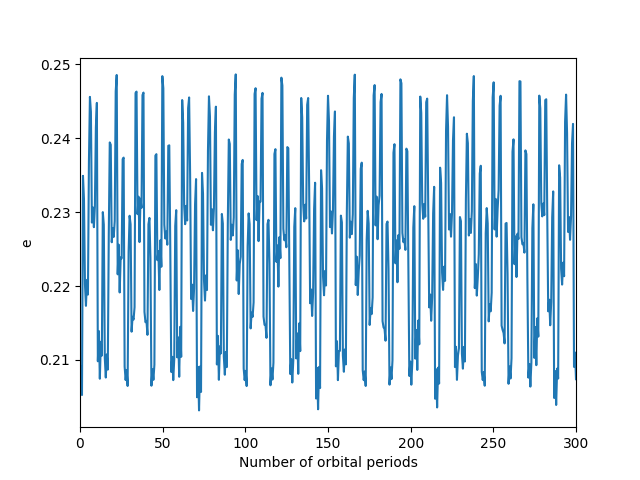

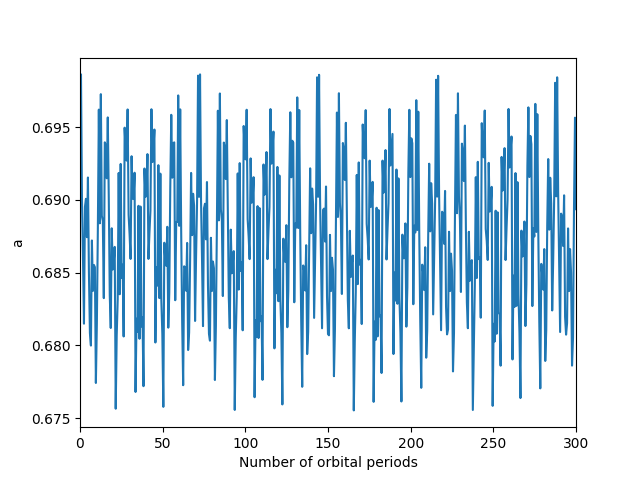

In [60]:
plt.close('all')

plt.figure(0)
plt.plot(times/p_orb, e1)
plt.xlim([0, 300])
#plt.ylim([0.2, 0.25])

plt.xlabel('Number of orbital periods')
plt.ylabel('e')

plt.figure(1)
plt.plot(times/p_orb, a1)
plt.xlim([0, 300])
#plt.ylim([0.675, 0.7])

plt.xlabel('Number of orbital periods')
plt.ylabel('a')

Chaotic orbit (fig 9.6):

In [61]:
print('e0 = '+str(e2[0]))
print('a0 = '+str(a2[0]))

e0 = 0.19924524983003775
a0 = 0.7022624118168437


Textbook values: a0 = 0.6984 and e0 = 0.1967

Text(0, 0.5, 'e')

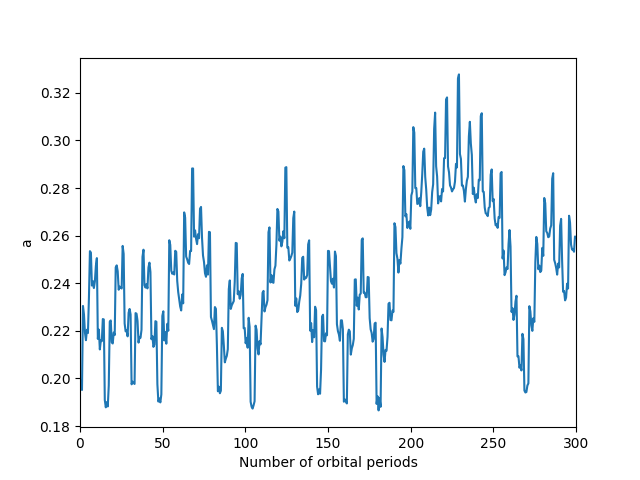

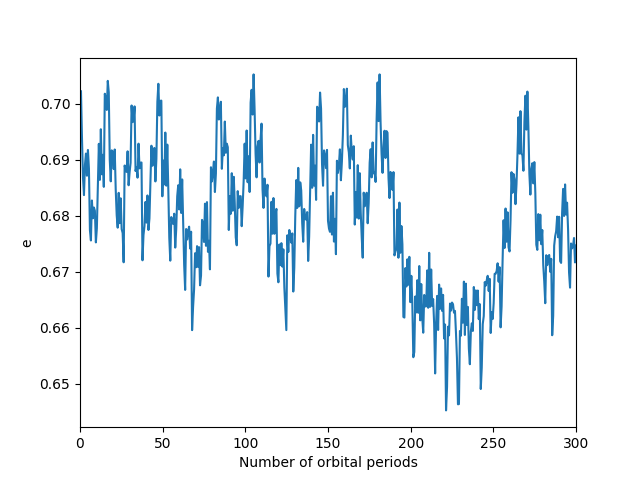

In [62]:
plt.close('all')

plt.figure(0)
plt.plot(times/p_orb, e2)
plt.xlim([0, 300])
#plt.ylim([0.675, 0.7])

plt.xlabel('Number of orbital periods')
plt.ylabel('a')

plt.figure(1)
plt.plot(times/p_orb, a2)
plt.xlim([0, 300])
#plt.ylim([0.18, 0.32])

plt.xlabel('Number of orbital periods')
plt.ylabel('e')

3.

-0.001 0.0 0.0
0.999 0.0 0.0
0.55 0.0 0.0
0.56 0.0 0.0
0.55001 0.0 0.0
0.56001 0.0 0.0
<rebound.Orbit instance, a=1.0 e=0.0 inc=0.0 Omega=0.0 omega=0.0 f=0.0> 6.283185307179586
<rebound.Orbit instance, a=0.6902041058011661 e=0.20313426799804646 inc=0.0 Omega=0.0 omega=0.0 f=0.0> 3.6028499569380177
<rebound.Orbit instance, a=0.6942557964002299 e=0.19338087934786657 inc=0.0 Omega=0.0 omega=0.0 f=0.0> 3.634621070674469
<rebound.Orbit instance, a=0.6902356029770618 e=0.2031561431665555 inc=0.0 Omega=0.0 omega=0.0 f=0.0> 3.603096581579565
<rebound.Orbit instance, a=0.6942865364413698 e=0.19340218972071202 inc=0.0 Omega=0.0 omega=0.0 f=0.0> 3.634862472270061


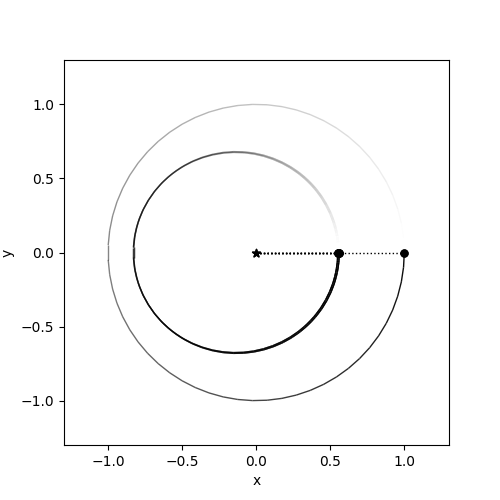

In [63]:
# set up the simulation
sim = rebound.Simulation()
sim.add(m=mu1, hash='sun')
sim.add(m=mu2, a=1, e=0, hash='jupiter')

sim.move_to_com()

sim.add(m=0, x=0.55, y=0, vx=0, vy = vy0_particle1_com, hash='particle1')
sim.add(m=0, x=0.56, y=0, vx=0, vy = vy0_particle2_com, hash='particle2')

sim.add(m=0, x=0.55 + 1e-5, y=0, vx=0, vy = vy0_particle1_com, hash='particle3')
sim.add(m=0, x=0.56 + 1e-5, y=0, vx=0, vy = vy0_particle2_com, hash='particle4')

# plot the positions and instantaneous orbit
op = rebound.OrbitPlot(sim, periastron=True)

# output info about the particles and the orbit
for p in sim.particles:
    print(p.x, p.y, p.z)
for o in sim.orbits(): 
    print(o, o.P)

In [64]:
p_orb = sim.particles['jupiter'].P

Norbits = 1000
Noutputs = 500

times = np.zeros(Noutputs)

xvec1 = [sim.particles['particle1'].x]
yvec1 = [sim.particles['particle1'].y]

vxvec1 = [sim.particles['particle1'].vx]
vyvec1 = [sim.particles['particle1'].vy]

xvec2 = [sim.particles['particle2'].x]
yvec2 = [sim.particles['particle2'].y]

vxvec2 = [sim.particles['particle2'].vx]
vyvec2 = [sim.particles['particle2'].vy]

xvec3 = [sim.particles['particle3'].x]
yvec3 = [sim.particles['particle3'].y]

vxvec3 = [sim.particles['particle3'].vx]
vyvec3 = [sim.particles['particle3'].vy]

xvec4 = [sim.particles['particle4'].x]
yvec4 = [sim.particles['particle4'].y]

vxvec4 = [sim.particles['particle4'].vx]
vyvec4 = [sim.particles['particle4'].vy]

a1 = np.zeros(Noutputs)
e1 = np.zeros(Noutputs)

a2 = np.zeros(Noutputs)
e2 = np.zeros(Noutputs)

a3 = np.zeros(Noutputs)
e3 = np.zeros(Noutputs)

a4 = np.zeros(Noutputs)
e4 = np.zeros(Noutputs)

op2, = plt.plot(xvec1, yvec1)

for i in range(Noutputs):
    op.sim.integrate(sim.t + (Norbits/Noutputs)*p_orb)

    times[i] = sim.t

    # store the trajectory + velocity of particle 1
    xvec1.append(sim.particles['particle1'].x)
    yvec1.append(sim.particles['particle1'].y)

    vxvec1.append(sim.particles['particle1'].vx)
    vyvec1.append(sim.particles['particle1'].vy)

    a1[i] = sim.particles['particle1'].a
    e1[i] = sim.particles['particle1'].e

    # store the trajectory + velocity of particle 2
    xvec2.append(sim.particles['particle2'].x)
    yvec2.append(sim.particles['particle2'].y)

    vxvec2.append(sim.particles['particle2'].vx)
    vyvec2.append(sim.particles['particle2'].vy)

    a2[i] = sim.particles['particle2'].a
    e2[i] = sim.particles['particle2'].e


    # store the trajectory + velocity of particle 3
    xvec3.append(sim.particles['particle3'].x)
    yvec3.append(sim.particles['particle3'].y)

    vxvec3.append(sim.particles['particle3'].vx)
    vyvec3.append(sim.particles['particle3'].vy)

    a3[i] = sim.particles['particle3'].a
    e3[i] = sim.particles['particle3'].e

    # store the trajectory + velocity of particle 4
    xvec4.append(sim.particles['particle4'].x)
    yvec4.append(sim.particles['particle4'].y)

    vxvec4.append(sim.particles['particle4'].vx)
    vyvec4.append(sim.particles['particle4'].vy)

    a4[i] = sim.particles['particle4'].a
    e4[i] = sim.particles['particle4'].e

    # update the plot to animate it
    op.update() #updateLimits=True) 
    op2.set_data((xvec1,yvec1)) 
    time.sleep(0.001)
    op.fig.canvas.draw()

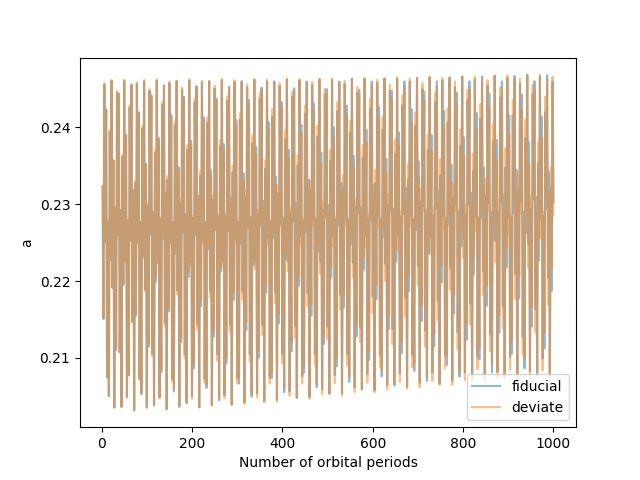

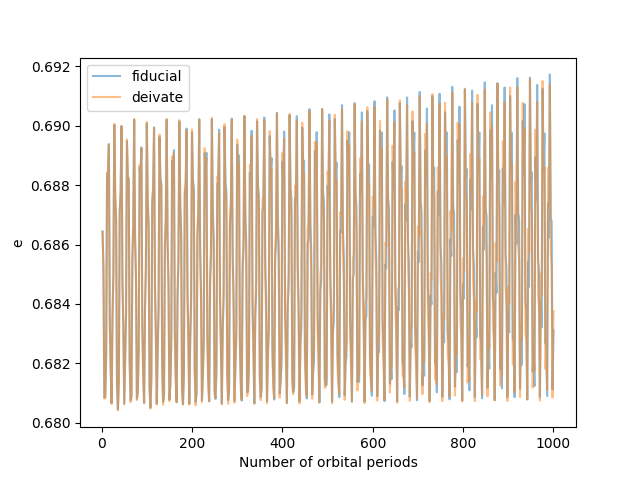

In [65]:
plt.close('all')

plt.figure(0)
plt.plot(times/p_orb, e1, label='fiducial', alpha=0.5)
plt.plot(times/p_orb, e3, label='deviate', alpha=0.5)
#plt.xlim([0, 300])
#plt.ylim([0.675, 0.7])

plt.xlabel('Number of orbital periods')
plt.ylabel('a')
plt.legend()

plt.figure(1)
plt.plot(times/p_orb, a1, label='fiducial', alpha=0.5)
plt.plot(times/p_orb, a3, label='deivate', alpha=0.5)

#plt.xlim([0, 300])
#plt.ylim([0.18, 0.32])

plt.xlabel('Number of orbital periods')
plt.ylabel('e')
plt.legend()

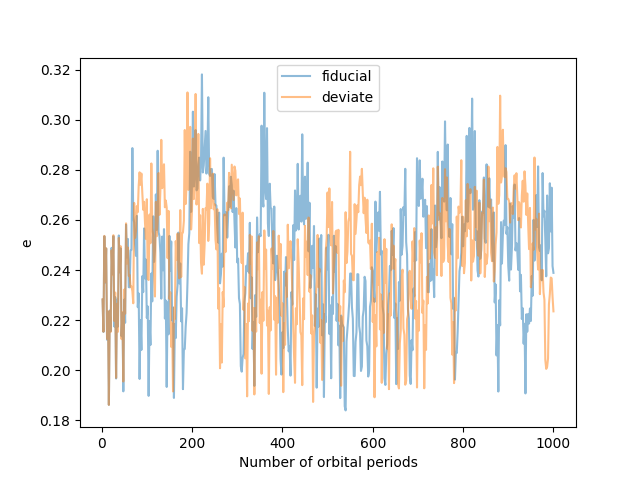

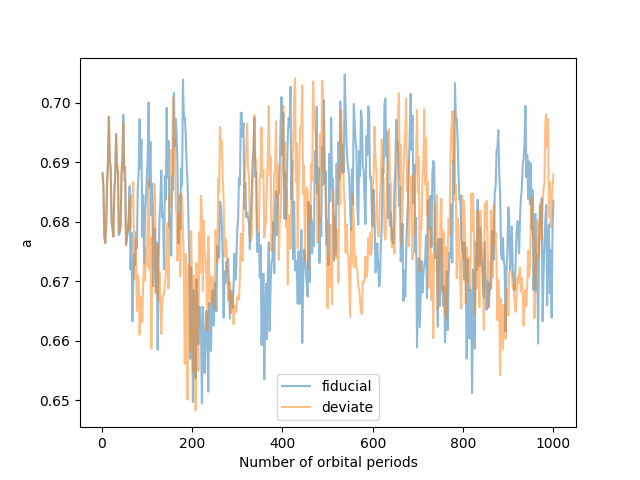

In [66]:
plt.close('all')

plt.figure(0)
plt.plot(times/p_orb, e2, label='fiducial', alpha=0.5)
plt.plot(times/p_orb, e4, label='deviate', alpha=0.5)
#plt.xlim([0, 300])
#plt.ylim([0.675, 0.7])

plt.xlabel('Number of orbital periods')
plt.ylabel('e')
plt.legend()

plt.figure(1)
plt.plot(times/p_orb, a2, label='fiducial', alpha=0.5)
plt.plot(times/p_orb, a4, label='deviate', alpha=0.5)

#plt.xlim([0, 300])
#plt.ylim([0.18, 0.32])

plt.xlabel('Number of orbital periods')
plt.ylabel('a')
plt.legend()

Zooming in to find point of departure:

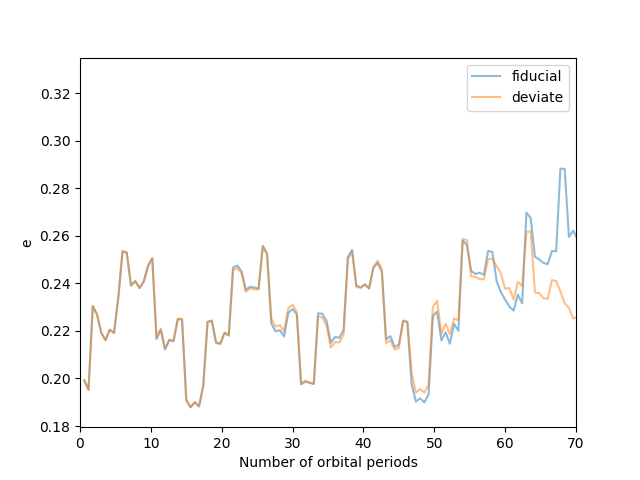

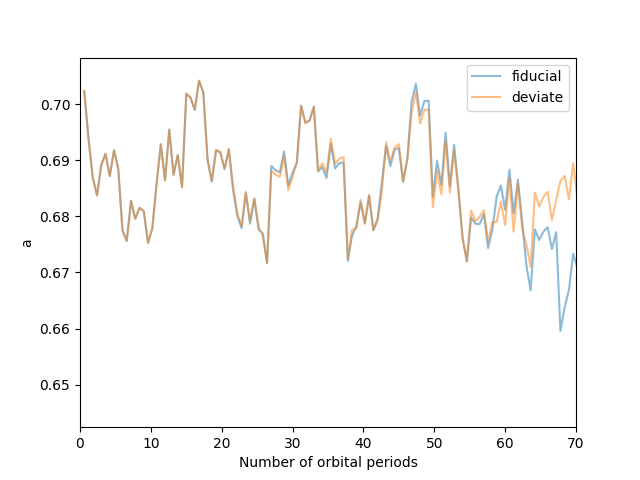

In [100]:
plt.close('all')

plt.figure(0)
plt.plot(times/p_orb, e2, label='fiducial', alpha=0.5)
plt.plot(times/p_orb, e4, label='deviate', alpha=0.5)
plt.xlim([0, 70])
#plt.ylim([0.675, 0.7])

plt.xlabel('Number of orbital periods')
plt.ylabel('e')
plt.legend()

plt.figure(1)
plt.plot(times/p_orb, a2, label='fiducial', alpha=0.5)
plt.plot(times/p_orb, a4, label='deviate', alpha=0.5)

plt.xlim([0, 70])
#plt.ylim([0.18, 0.32])

plt.xlabel('Number of orbital periods')
plt.ylabel('a')
plt.legend()

4. 

In [78]:
def dfunc(x1, y1, x2, y2, vx1, vy1, vx2, vy2):
    return np.sqrt((x1-x2)**2 + (y1-y2)**2 + (vx1-vx2)**2 + (vy1-vy2)**2)

def LCE(x1_0, x1, y1_0, y1, x2_0, x2, y2_0, y2, vx1_0, vx1, vy1_0, vy1, vx2_0, vx2, vy2_0, vy2, t0, t):

    d = dfunc(x1, y1, x2, y2, vx1, vy1, vx2, vy2)
    d0 = dfunc(x1_0, y1_0, x2_0, y2_0, vx1_0, vy1_0, vx2_0, vy2_0)
    
    gamma = np.log(d/d0)/(t-t0)
    
    return gamma

In [67]:
def make_LCEs(xvec1, yvec1, xvec2, yvec2, vxvec1, vyvec1, vxvec2, vyvec2, times):

    LCEs = np.zeros(Noutputs)

    for i in range(Noutputs):
        if i==0:
            continue # skip i=0
    
        x1_0 = xvec1[0]
        y1_0 = yvec1[0]
        x2_0 = xvec2[0]
        y2_0 = yvec2[0]
        
        vx1_0 = vxvec1[0]
        vy1_0 = vyvec1[0]
        vx2_0 = vxvec2[0]
        vy2_0 = vyvec2[0]
    
        LCEs[i] = LCE(x1_0  = x1_0,
                      x1    = xvec1[i],
                      y1_0  = y1_0,
                      y1    = yvec1[i],
                      x2_0  = x2_0,
                      x2    = xvec2[i],
                      y2_0  = y2_0,
                      y2    = yvec2[i],
                      vx1_0 = vx1_0, 
                      vx1   = vxvec1[i],
                      vy1_0 = vy1_0,
                      vy1   = vyvec1[i],
                      vx2_0 = vx2_0,
                      vx2   = vxvec2[i],
                      vy2_0 = vy2_0,
                      vy2   = vyvec2[i],
                      t0    = times[0], 
                      t     = times[i]
                   )

    return LCEs

In [68]:
LCE_13 = make_LCEs(xvec1=xvec1,
                   yvec1=yvec1,
                   xvec2=xvec3,
                   yvec2=yvec3,
                   vxvec1=vxvec1,
                   vyvec1=vyvec1,
                   vxvec2=vxvec3,
                   vyvec2=vyvec3,
                   times=times)

In [69]:
LCE_24 = make_LCEs(xvec1=xvec2,
                   yvec1=yvec2,
                   xvec2=xvec4,
                   yvec2=yvec4,
                   vxvec1=vxvec2,
                   vyvec1=vyvec2,
                   vxvec2=vxvec4,
                   vyvec2=vyvec4,
                   times=times)

Text(0.5, 0, 'Number of orbital periods')

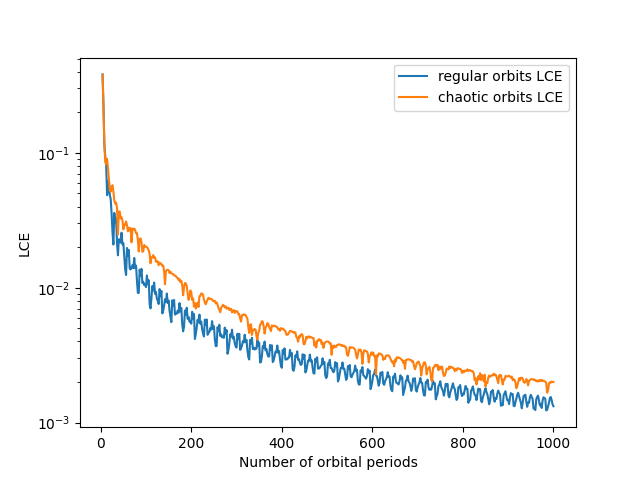

In [85]:
plt.close('all')
plt.plot(times[1:]/p_orb, LCE_13[1:], label='regular orbits LCE')
plt.plot(times[1:]/p_orb, LCE_24[1:], label='chaotic orbits LCE')
plt.yscale('log')
plt.legend()

plt.ylabel('LCE')
plt.xlabel('Number of orbital periods')

5. 

-0.001 0.0 0.0
0.999 0.0 0.0
0.55 0.0 0.0
0.56 0.0 0.0
0.55001 0.0 0.0
0.56001 0.0 0.0
<rebound.Orbit instance, a=1.0 e=0.0 inc=0.0 Omega=0.0 omega=0.0 f=0.0> 6.283185307179586
<rebound.Orbit instance, a=0.6902041058011661 e=0.20313426799804646 inc=0.0 Omega=0.0 omega=0.0 f=0.0> 3.6028499569380177
<rebound.Orbit instance, a=0.6942557964002299 e=0.19338087934786657 inc=0.0 Omega=0.0 omega=0.0 f=0.0> 3.634621070674469
<rebound.Orbit instance, a=0.6902356029770618 e=0.2031561431665555 inc=0.0 Omega=0.0 omega=0.0 f=0.0> 3.603096581579565
<rebound.Orbit instance, a=0.6942865364413698 e=0.19340218972071202 inc=0.0 Omega=0.0 omega=0.0 f=0.0> 3.634862472270061


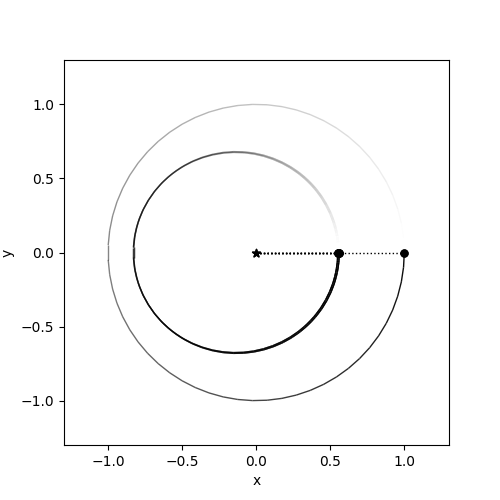

In [344]:
# set up the simulation
sim = rebound.Simulation()
sim.add(m=mu1, hash='sun')
sim.add(m=mu2, a=1, e=0, hash='jupiter')

sim.move_to_com()

sim.add(m=0, x=0.55, y=0, vx=0, vy = vy0_particle1_com, hash='particle1')
sim.add(m=0, x=0.56, y=0, vx=0, vy = vy0_particle2_com, hash='particle2')

sim.add(m=0, x=0.55 + 1e-5, y=0, vx=0, vy = vy0_particle1_com, hash='particle3')
sim.add(m=0, x=0.56 + 1e-5, y=0, vx=0, vy = vy0_particle2_com, hash='particle4')

# plot the positions and instantaneous orbit
op = rebound.OrbitPlot(sim, periastron=True)

# output info about the particles and the orbit
for p in sim.particles:
    print(p.x, p.y, p.z)
for o in sim.orbits(): 
    print(o, o.P)

In [345]:
p_orb = sim.particles['jupiter'].P

Norbits = 10*60
Noutputs = 500*60

times = np.zeros(Noutputs)

xvec1 = [sim.particles['particle1'].x]
yvec1 = [sim.particles['particle1'].y]

vxvec1 = [sim.particles['particle1'].vx]
vyvec1 = [sim.particles['particle1'].vy]

xvec2 = [sim.particles['particle2'].x]
yvec2 = [sim.particles['particle2'].y]

vxvec2 = [sim.particles['particle2'].vx]
vyvec2 = [sim.particles['particle2'].vy]

xvec3 = [sim.particles['particle3'].x]
yvec3 = [sim.particles['particle3'].y]

vxvec3 = [sim.particles['particle3'].vx]
vyvec3 = [sim.particles['particle3'].vy]

xvec4 = [sim.particles['particle4'].x]
yvec4 = [sim.particles['particle4'].y]

vxvec4 = [sim.particles['particle4'].vx]
vyvec4 = [sim.particles['particle4'].vy]

a1 = np.zeros(Noutputs)
e1 = np.zeros(Noutputs)

a2 = np.zeros(Noutputs)
e2 = np.zeros(Noutputs)

a3 = np.zeros(Noutputs)
e3 = np.zeros(Noutputs)

a4 = np.zeros(Noutputs)
e4 = np.zeros(Noutputs)

op2, = plt.plot(xvec1, yvec1)

for i in range(Noutputs):
    op.sim.integrate(sim.t + (Norbits/Noutputs)*p_orb)

    times[i] = sim.t

    # store the trajectory + velocity of particle 1
    xvec1.append(sim.particles['particle1'].x)
    yvec1.append(sim.particles['particle1'].y)

    vxvec1.append(sim.particles['particle1'].vx)
    vyvec1.append(sim.particles['particle1'].vy)

    a1[i] = sim.particles['particle1'].a
    e1[i] = sim.particles['particle1'].e

    # store the trajectory + velocity of particle 2
    xvec2.append(sim.particles['particle2'].x)
    yvec2.append(sim.particles['particle2'].y)

    vxvec2.append(sim.particles['particle2'].vx)
    vyvec2.append(sim.particles['particle2'].vy)

    a2[i] = sim.particles['particle2'].a
    e2[i] = sim.particles['particle2'].e


    # store the trajectory + velocity of particle 3
    xvec3.append(sim.particles['particle3'].x)
    yvec3.append(sim.particles['particle3'].y)

    vxvec3.append(sim.particles['particle3'].vx)
    vyvec3.append(sim.particles['particle3'].vy)

    a3[i] = sim.particles['particle3'].a
    e3[i] = sim.particles['particle3'].e

    # store the trajectory + velocity of particle 4
    xvec4.append(sim.particles['particle4'].x)
    yvec4.append(sim.particles['particle4'].y)

    vxvec4.append(sim.particles['particle4'].vx)
    vyvec4.append(sim.particles['particle4'].vy)

    a4[i] = sim.particles['particle4'].a
    e4[i] = sim.particles['particle4'].e

    # update the plot to animate it
    op.update() #updateLimits=True) 
    op2.set_data((xvec1,yvec1)) 
    time.sleep(0.001)
    op.fig.canvas.draw()

Acutally: need to transform to corotating frame!

In [212]:
def xy_from_corot_to_com(x, y, t, n=1):
    
    "equation 3.10 in Murray&Dermott"
    
    xi = x*np.cos(n*t) - y*np.sin(n*t)
    eta = x*np.sin(n*t) + y*np.cos(n*t)
    
    return xi, eta

In [213]:
def v_from_corot_to_com(vx, vy, x, y, t, n=1):
    
    "equation 3.11 in Murray&Dermott"
    
    xi_dot = (vx - n*y)*np.cos(n*t) - (vy + n*x)*np.sin(n*t)
    eta_dot = (vx - n*y)*np.sin(n*t) + (vy + n*x)*np.cos(n*t)
    
    return xi_dot, eta_dot

In [214]:
def xy_from_com_to_corot(xi, eta, t, n=1):
    
    x = xi*np.cos(n*t) + eta*np.sin(n*t)
    y = -xi*np.sin(n*t) + eta*np.cos(n*t)
    
    return x, y

In [215]:
def v_from_com_to_corot(xi_dot, eta_dot, xi, eta, t, n=1):
    
    vx_corot = (xi_dot + n*eta)*np.cos(n*t) + (eta_dot - n*xi)*np.sin(n*t)
    vy_corot = -(xi_dot + n*eta)*np.sin(n*t) + (eta_dot - n*xi)*np.cos(n*t)
    
    return vx_corot, vy_corot

Let's check that it's behaving properly. Take example x, y, vx, vy in COM frame (where x and y are noted $\xi$ and $\eta$ in Murray & Dermott for the COM frame), transform to corotating frame (in $x$ and $y$, again per Murray and Dermott notation for the corotating frame), and transform back to the COM frame. It should go back to the same values I started with, if my transformation matrices are good.

In [216]:
times_test = list(times)
times_test.insert(0, 0)
times_test = np.array(times_test)
len(times_test)

501

In [217]:
xi_test = np.array(xvec1)
eta_test = np.array(yvec1)

xi_dot_test = np.array(vxvec1)
eta_dot_test = np.array(vyvec1)

x_test, y_test = xy_from_com_to_corot(xi=xi_test, eta=eta_test, t=times_test, n=1)
vx_test, vy_test = v_from_com_to_corot(xi_dot=xi_dot_test, eta_dot=eta_dot_test, xi=xi_test, eta=eta_test, t=times_test, n=1)

xi_double, eta_double = xy_from_corot_to_com(x=x_test, y=y_test, t=times_test, n=1)
xi_dot_double, eta_dot_double = v_from_corot_to_com(vx=vx_test, vy=vy_test, x=x_test, y=y_test, t=times_test, n=1)

Text(0.5, 1.0, '$\\xi$ initial - final')

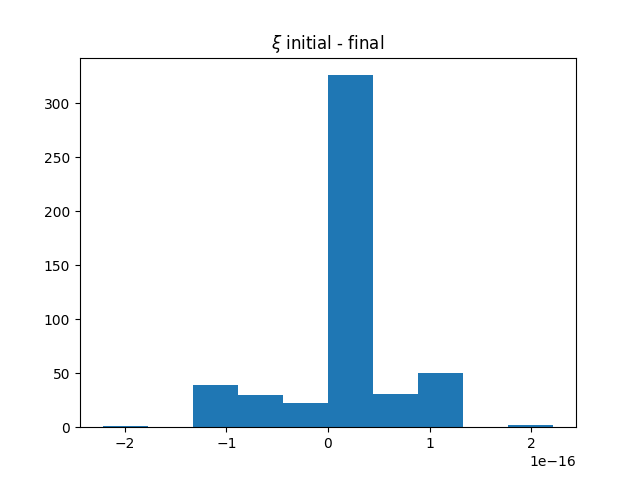

In [218]:
plt.close('all')
plt.hist(xi_test - xi_double)
plt.title(r'$\xi$ initial - final')

Text(0.5, 1.0, '$\\eta$ initial - final')

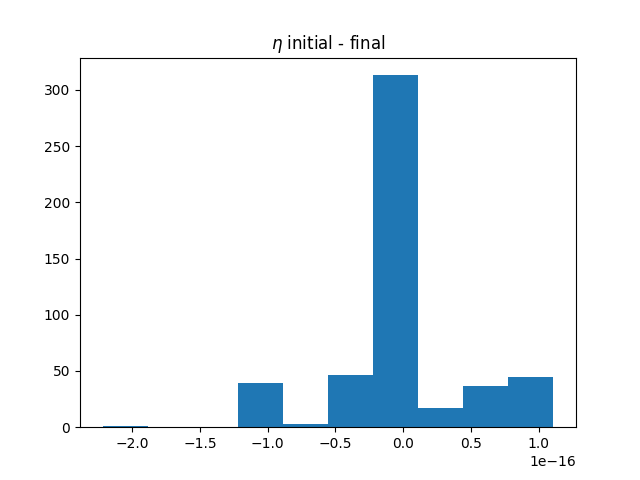

In [219]:
plt.close('all')
plt.hist(eta_test - eta_double)
plt.title(r'$\eta$ initial - final')

Text(0.5, 1.0, '$\\dot{\\xi}$ initial - final')

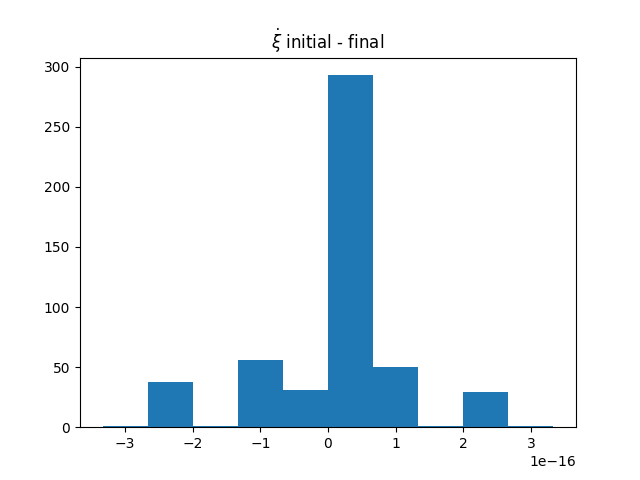

In [220]:
plt.close('all')
plt.hist(xi_dot_test - xi_dot_double)
plt.title(r'$\dot{\xi}$ initial - final')

Text(0.5, 1.0, '$\\dot{\\eta}$ initial - final')

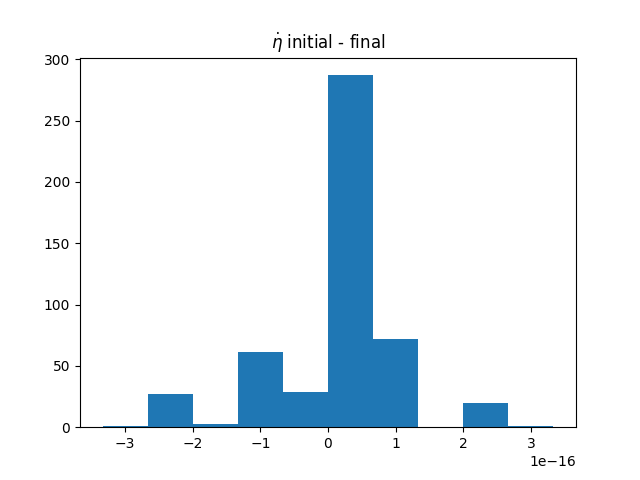

In [221]:
plt.close('all')
plt.hist(eta_dot_test - eta_dot_double)
plt.title(r'$\dot{\eta}$ initial - final')

Differences are of order 1e-16.. that's close enough to 0 to say that the transformations are good enough, I think !

In [315]:
# ---- turn lists to arrays for functionalization ----

times_test = list(times)
times_test.insert(0, 0)
times_test = np.array(times_test)

xvec1 = np.array(xvec1)
yvec1 = np.array(yvec1)

xvec2 = np.array(xvec2)
yvec2 = np.array(yvec2)

xvec3 = np.array(xvec3)
yvec3 = np.array(yvec3)

xvec4 = np.array(xvec4)
yvec4 = np.array(yvec4)

vxvec1 = np.array(vxvec1)
vyvec1 = np.array(vyvec1)

vxvec2 = np.array(vxvec2)
vyvec2 = np.array(vyvec2)

vxvec3 = np.array(vxvec3)
vyvec3 = np.array(vyvec3)

vxvec4 = np.array(vxvec4)
vyvec4 = np.array(vyvec4)

# ---- transform to corotating frame ----

xvec1_corot, yvec1_corot = xy_from_com_to_corot(xi=xvec1, eta=yvec1, t=times_test, n=1)
xvec2_corot, yvec2_corot = xy_from_com_to_corot(xi=xvec2, eta=yvec2, t=times_test, n=1)
xvec3_corot, yvec3_corot = xy_from_com_to_corot(xi=xvec3, eta=yvec3, t=times_test, n=1)
xvec4_corot, yvec4_corot = xy_from_com_to_corot(xi=xvec4, eta=yvec4, t=times_test, n=1)

vxvec1_corot, vyvec1_corot = v_from_com_to_corot(xi_dot=vxvec1, eta_dot=vyvec1, xi=xvec1, eta=yvec1, t=times_test, n=1)
vxvec2_corot, vyvec2_corot = v_from_com_to_corot(xi_dot=vxvec2, eta_dot=vyvec2, xi=xvec2, eta=yvec2, t=times_test, n=1)
vxvec3_corot, vyvec3_corot = v_from_com_to_corot(xi_dot=vxvec3, eta_dot=vyvec3, xi=xvec3, eta=yvec3, t=times_test, n=1)
vxvec4_corot, vyvec4_corot = v_from_com_to_corot(xi_dot=vxvec4, eta_dot=vyvec4, xi=xvec4, eta=yvec4, t=times_test, n=1)

Now, we want to select the points for which the y position (`yvec`) are zero and the y velocity (`vyvec`) is positive. The idea is that when you take `np.sign()` of `yvec`, it returns either 1 or -1. Then, if you take `np.diff()` of it, it will tell you what is the change between two consecutive values of `np.sign(yvec)`. Therefore, if values of `yvec` are positive and remain positive, `np.sign(yvec)` will just be 1's, and `np.diff(np.sign(yvec))` will just be 0's. Then, the moment one value of `yvec` turns negative, `np.sign(yvec)` turns from +1 to -1, such that `np.diff(np.sign(yvec))` turns to -2. Inversely, if `yvec` turns from a negative to a positive value, `np.diff(np.sign(yvec))` turns to +2. Since we are interested in the points where `yvec = 0` and `vyvec > 0`, we are looking for the points for which `np.diff(np.sign(yvec)) == 2`. Thanks to Shu for sharing this trick:-)

In [336]:
ind_y0_vypos_1 = np.diff(np.sign(yvec1_corot)) == 2
inds1 = np.where(ind_y0_vypos_1)

ind_y0_vypos_2 = np.diff(np.sign(yvec2_corot)) == 2
inds2 = np.where(ind_y0_vypos_2)

ind_y0_vypos_3 = np.diff(np.sign(yvec3_corot)) == 2
inds3 = np.where(ind_y0_vypos_3)

ind_y0_vypos_4 = np.diff(np.sign(yvec4_corot)) == 2
inds4 = np.where(ind_y0_vypos_4)

(0.0, 100.0)

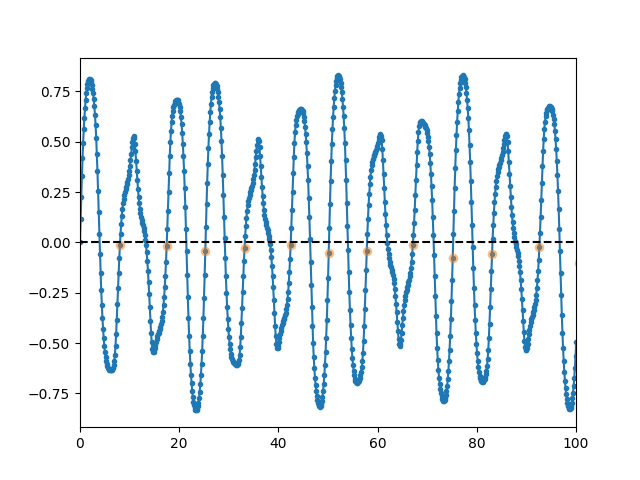

In [338]:
plt.close('all')
plt.plot(times_test, yvec1_corot, '.-')
plt.plot(times_test[0:-1][ind_y0_vypos_1], yvec1_corot[0:-1][ind_y0_vypos_1], 'o', alpha=0.4)

plt.axhline(y=0, linestyle='--', color='k')

plt.xlim([0, 100])

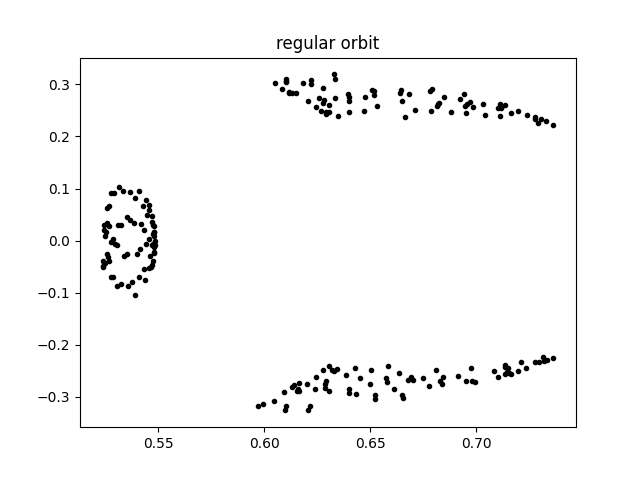

In [342]:
xvec1_crop = xvec1_corot[0:-1]
vxvec1_crop = vxvec1_corot[0:-1]

plt.close('all')
plt.title('regular orbit')
for i in range(len(inds1)):
    middle_x  = 0.5*(xvec1_crop[inds1[i]] + xvec1_crop[inds1[i] +1])
    middle_vx = 0.5*(vxvec1_crop[inds1[i]] + vxvec1_crop[inds1[i] +1])

    normal_x = 0.5*(xvec1_crop[inds1[i]] + xvec1_crop[inds1[i]])
    normal_vx = 0.5*(vxvec1_crop[inds1[i]] + vxvec1_crop[inds1[i]])
    plt.scatter(middle_x, middle_vx, color='k', marker='.')

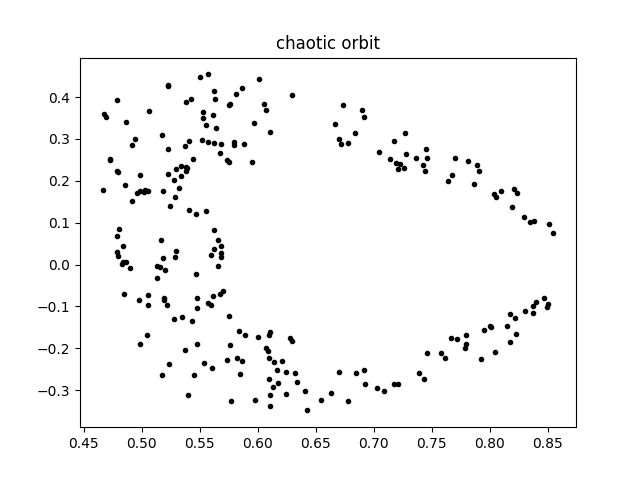

In [327]:
xvec2_crop = xvec2_corot[0:-1]
vxvec2_crop = vxvec2_corot[0:-1]

plt.close('all')
plt.title('chaotic orbit')
plt.scatter(xvec2_crop[ind_y0_vypos_2], vxvec2_crop[ind_y0_vypos_2], color='k', marker='.')

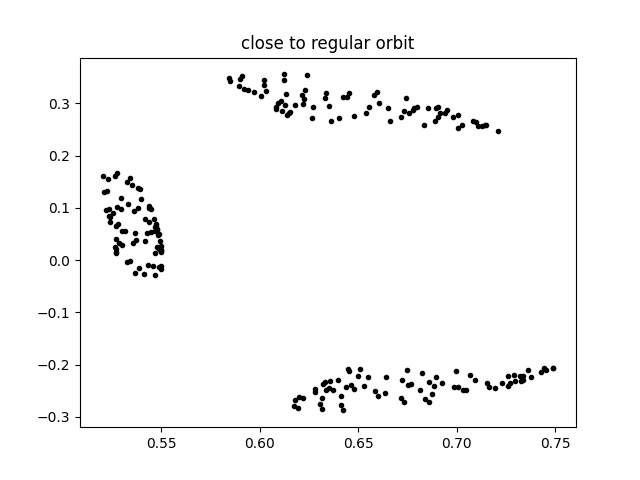

In [328]:
xvec3_crop = xvec3_corot[0:-1]
vxvec3_crop = vxvec3_corot[0:-1]

plt.close('all')
plt.title('close to regular orbit')
plt.scatter(xvec3_crop[ind_y0_vypos_3], vxvec3_crop[ind_y0_vypos_3], color='k', marker='.')

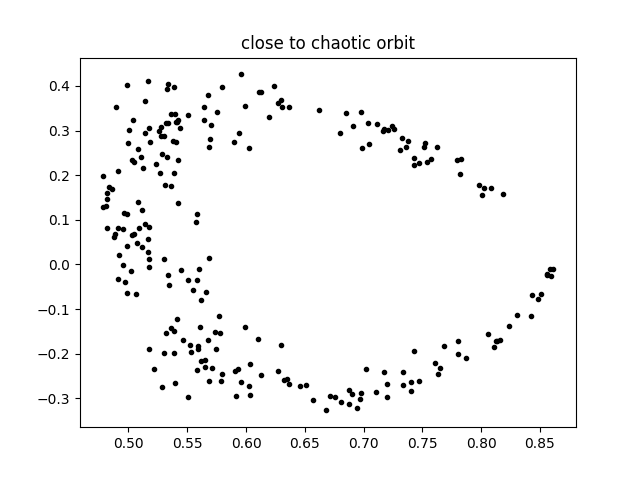

In [329]:
xvec4_crop = xvec4_corot[0:-1]
vxvec4_crop = vxvec4_corot[0:-1]

plt.close('all')
plt.title('close to chaotic orbit')
plt.scatter(xvec4_crop[ind_y0_vypos_4], vxvec4_crop[ind_y0_vypos_4], color='k', marker='.')